In [7]:
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
import numpy as np
from scipy.stats import mode
from sklearn.metrics import silhouette_score, classification_report

In [8]:
train_df = pd.read_csv('../Data/Data_finance_lab3_featured.csv')
y = train_df['RESULT_YES/NO']

In [9]:
train_df.drop(['ID'], axis=1, inplace=True)

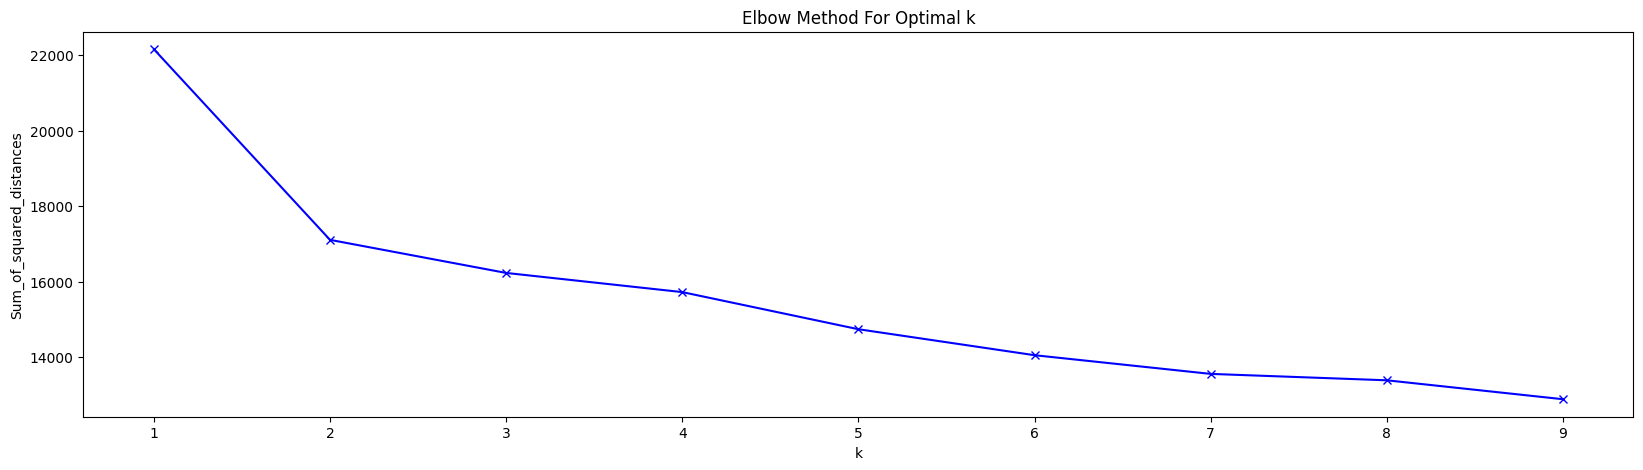

In [10]:
scaler = RobustScaler(quantile_range=(15, 85))
cluster_scaled = scaler.fit_transform(train_df)

Sum_of_squared_distances = []
K = range(1,10)
for k in K:
    km = KMeans(n_clusters=k, random_state=0, init='k-means++', 
            max_iter=100, n_init=1, verbose=0,)
    km = km.fit(cluster_scaled)
    Sum_of_squared_distances.append(km.inertia_)
plt.figure(figsize=(20,5))
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [11]:
model = KMeans(n_clusters=4, random_state=0, init='k-means++', 
            max_iter=100, n_init=1, verbose=0,)
y_pred_clusters =model.fit_predict(cluster_scaled)

In [12]:
labels = np.zeros_like(y_pred_clusters)
for i in range(model.n_clusters):
    mask = (y_pred_clusters == i)
    labels[mask] = mode(y[mask])[0]
print(classification_report(y, labels))

              precision    recall  f1-score   support

           0       0.61      0.61      0.61      1364
           1       0.85      0.85      0.85      3636

    accuracy                           0.79      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.79      0.79      0.79      5000

